# 04 — Enhanced RFM
**Construct RFM and enhanced behavioral features for customer segmentation.**


## Objective
- Define the purpose of this stage.
- Record key decisions and assumptions.
- Keep outputs reproducible and easy to trace to the previous stage.


## Features
Traditional RFM: Recency, Frequency, Monetary

Enhanced features: Average Transaction Value, Average Basket Size, Amount Slope, Frequency Slope


## Feature preparation
Inspect distributions, apply justified transformations to skewed variables, assemble features, and standardize them before clustering.


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ECommerceCustomerBehaviorAnalytics-04-EnhancedRFM")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.2.0


In [3]:
CUSTOMER_ANALYTICS_PATH = "../data/customer_analytics_oct.parquet"

customer_analytics = spark.read.parquet(
    CUSTOMER_ANALYTICS_PATH
)

print("Rows:", customer_analytics.count())
print("Columns:", len(customer_analytics.columns))

customer_analytics.printSchema()

Rows: 347118
Columns: 18
root
 |-- user_id: integer (nullable = true)
 |-- purchase_events: long (nullable = true)
 |-- purchase_sessions: long (nullable = true)
 |-- unique_products: long (nullable = true)
 |-- total_spend: double (nullable = true)
 |-- avg_purchase_value: double (nullable = true)
 |-- first_purchase: timestamp (nullable = true)
 |-- last_purchase: timestamp (nullable = true)
 |-- view_events: long (nullable = true)
 |-- cart_events: long (nullable = true)
 |-- view_to_cart_rate: double (nullable = true)
 |-- cart_to_purchase_rate: double (nullable = true)
 |-- purchase_to_view_rate: double (nullable = true)
 |-- spend_per_purchase_session: double (nullable = true)
 |-- purchases_per_session: double (nullable = true)
 |-- views_per_purchase: double (nullable = true)
 |-- spend_segment: string (nullable = true)
 |-- recency_days: integer (nullable = true)



In [4]:
from pyspark.sql.functions import col, when

enhanced_rfm = (
    customer_analytics
    .select(
        "user_id",
        "recency_days",
        "purchase_events",
        "total_spend",
        "avg_purchase_value",
        "purchase_sessions"
    )
    .withColumnRenamed("purchase_events", "frequency")
    .withColumnRenamed("total_spend", "monetary")
    .withColumnRenamed("avg_purchase_value", "average_transaction_value")
    .withColumn(
        "avg_purchase_events_per_session",
        when(
            col("purchase_sessions") > 0,
            col("frequency") / col("purchase_sessions")
        ).otherwise(0)
    )
)

print("Customers:", enhanced_rfm.count())
enhanced_rfm.show(10, truncate=False)

Customers: 347118
+---------+------------+---------+--------+-------------------------+-----------------+-------------------------------+
|user_id  |recency_days|frequency|monetary|average_transaction_value|purchase_sessions|avg_purchase_events_per_session|
+---------+------------+---------+--------+-------------------------+-----------------+-------------------------------+
|303160429|19          |1        |340.59  |340.59                   |1                |1.0                            |
|427151532|16          |1        |177.35  |177.35                   |1                |1.0                            |
|427391662|16          |2        |430.46  |215.23                   |2                |1.0                            |
|434170823|6           |3        |2112.54 |704.18                   |3                |1.0                            |
|434350078|3           |1        |128.45  |128.45                   |1                |1.0                            |
|438992161|29         

In [5]:
from pyspark.sql.functions import (
    col,
    min as spark_min,
    unix_timestamp,
    when,
    expr
)

# Purchase events only
purchase_events = (
    spark.read.parquet(CUSTOMER_ANALYTICS_PATH)
    .select(
        "user_id",
        "first_purchase"
    )
)

# Use the original cleaned event data for purchase-level amounts and dates
purchase_transactions = (
    spark.read.parquet("../data/cleaned_ecommerce_oct.parquet")
    .filter(col("event_type") == "purchase")
    .select(
        "user_id",
        "event_time",
        "price"
    )
)

# Calculate days since each customer's first purchase
purchase_with_time = (
    purchase_transactions
    .join(
        purchase_events,
        on="user_id",
        how="inner"
    )
    .withColumn(
        "days_since_first",
        (
            unix_timestamp(col("event_time")) -
            unix_timestamp(col("first_purchase"))
        ) / 86400.0
    )
)

# Linear regression slope of purchase amount over time
amount_slope = (
    purchase_with_time
    .groupBy("user_id")
    .agg(
        expr("regr_slope(price, days_since_first)")
        .alias("amount_slope")
    )
    .fillna(0, subset=["amount_slope"])
)

print("Customers with amount slope:", amount_slope.count())

amount_slope.show(10, truncate=False)

Customers with amount slope: 347118


[Stage 18:========================>                                (6 + 8) / 14]

+---------+---------------------+
|user_id  |amount_slope         |
+---------+---------------------+
|553531404|0.0                  |
|518503811|-0.6831175795629243  |
|552722013|0.0                  |
|516729759|-0.024260354853956695|
|514292886|0.0                  |
|539885835|-4.16139452448401    |
|559693351|-7.979767525882361   |
|526688298|3.1087449969035315   |
|514682764|7.894416243654823    |
|512593237|0.0                  |
+---------+---------------------+
only showing top 10 rows


In [6]:
from pyspark.sql.functions import (
    col,
    datediff,
    to_date,
    floor,
    count,
    expr
)

purchase_frequency_over_time = (
    purchase_transactions
    .join(
        purchase_events,
        on="user_id",
        how="inner"
    )
    .withColumn(
        "week_index",
        floor(
            datediff(
                to_date(col("event_time")),
                to_date(col("first_purchase"))
            ) / 7
        )
    )
)

weekly_frequency = (
    purchase_frequency_over_time
    .groupBy("user_id", "week_index")
    .agg(
        count("*").alias("weekly_purchase_frequency")
    )
)

frequency_slope = (
    weekly_frequency
    .groupBy("user_id")
    .agg(
        expr(
            "regr_slope(weekly_purchase_frequency, week_index)"
        ).alias("frequency_slope")
    )
    .fillna(0, subset=["frequency_slope"])
)

print("Customers with frequency slope:", frequency_slope.count())

frequency_slope.show(10, truncate=False)

Customers with frequency slope: 347118


[Stage 29:========================================>               (10 + 4) / 14]

+---------+---------------+
|user_id  |frequency_slope|
+---------+---------------+
|519244676|0.0            |
|556824784|0.0            |
|543470710|0.0            |
|560368067|0.0            |
|522699937|0.0            |
|526986520|-0.5           |
|518284362|-1.0           |
|522434437|0.0            |
|521748533|0.0            |
|536025714|-0.8           |
+---------+---------------+
only showing top 10 rows


In [7]:
enhanced_rfm = (
    enhanced_rfm
    .join(
        amount_slope,
        on="user_id",
        how="left"
    )
    .join(
        frequency_slope,
        on="user_id",
        how="left"
    )
    .fillna(0, subset=["amount_slope", "frequency_slope"])
)

print("Customers:", enhanced_rfm.count())
print("Features:", len(enhanced_rfm.columns))

enhanced_rfm.printSchema()
enhanced_rfm.show(10, truncate=False)

Customers: 347118
Features: 9
root
 |-- user_id: integer (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- average_transaction_value: double (nullable = true)
 |-- purchase_sessions: long (nullable = true)
 |-- avg_purchase_events_per_session: double (nullable = true)
 |-- amount_slope: double (nullable = false)
 |-- frequency_slope: double (nullable = false)



[Stage 41:========================================>               (10 + 4) / 14]

+---------+------------+---------+------------------+-------------------------+-----------------+-------------------------------+-------------------+---------------+
|user_id  |recency_days|frequency|monetary          |average_transaction_value|purchase_sessions|avg_purchase_events_per_session|amount_slope       |frequency_slope|
+---------+------------+---------+------------------+-------------------------+-----------------+-------------------------------+-------------------+---------------+
|396222093|8           |1        |48.14             |48.14                    |1                |1.0                            |0.0                |0.0            |
|420935067|25          |1        |385.84            |385.84                   |1                |1.0                            |0.0                |0.0            |
|425101109|21          |1        |84.17             |84.17                    |1                |1.0                            |0.0                |0.0            |
|427

In [8]:
enhanced_rfm.select(
    "amount_slope",
    "frequency_slope"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "90%",
    "95%",
    "99%",
    "max"
).show()

[Stage 59:>                                                       (0 + 10) / 11]

+-------+-------------------+--------------------+
|summary|       amount_slope|     frequency_slope|
+-------+-------------------+--------------------+
|  count|             347118|              347118|
|   mean| -2058.633068556326|-0.07909154970197613|
| stddev| 33445.585495264146|   0.971037449876579|
|    min|-2265743.0204081633|               -80.0|
|    25%|                0.0|                 0.0|
|    50%|                0.0|                 0.0|
|    75%|                0.0|                 0.0|
|    90%|  3.932099351910873|                 0.0|
|    95%|  31.26664299410553|                 0.0|
|    99%|  4880.780646417411|                 1.0|
|    max| 1255793.4545454544|               117.0|
+-------+-------------------+--------------------+



In [9]:
enhanced_rfm = (
    enhanced_rfm
    .select(
        "user_id",
        "recency_days",
        "frequency",
        "monetary",
        "average_transaction_value",
        "avg_purchase_events_per_session",
        "amount_slope",
        "frequency_slope"
    )
)

print("Customers:", enhanced_rfm.count())
print("Total columns:", len(enhanced_rfm.columns))
print("Modeling features:", len(enhanced_rfm.columns) - 1)

enhanced_rfm.printSchema()

Customers: 347118
Total columns: 8
Modeling features: 7
root
 |-- user_id: integer (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- average_transaction_value: double (nullable = true)
 |-- avg_purchase_events_per_session: double (nullable = true)
 |-- amount_slope: double (nullable = false)
 |-- frequency_slope: double (nullable = false)



In [10]:
ENHANCED_RFM_PATH = "../data/enhanced_rfm_oct.parquet"

enhanced_rfm.write.mode("overwrite").parquet(ENHANCED_RFM_PATH)

print("Enhanced RFM dataset saved successfully.")
print("Path:", ENHANCED_RFM_PATH)

26/09/28 21:37:41 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/28 21:37:41 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/28 21:37:41 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers


Enhanced RFM dataset saved successfully.
Path: ../data/enhanced_rfm_oct.parquet


26/09/28 21:37:41 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/28 21:37:41 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
                                                                                

In [11]:
saved_rfm = spark.read.parquet(ENHANCED_RFM_PATH)

print("Rows:", saved_rfm.count())
print("Columns:", len(saved_rfm.columns))

saved_rfm.printSchema()

Rows: 347118
Columns: 8
root
 |-- user_id: integer (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- average_transaction_value: double (nullable = true)
 |-- avg_purchase_events_per_session: double (nullable = true)
 |-- amount_slope: double (nullable = true)
 |-- frequency_slope: double (nullable = true)



In [12]:
from pyspark.sql.functions import col, log1p, signum, abs

model_features = [
    "recency_days",
    "frequency",
    "monetary",
    "average_transaction_value",
    "avg_purchase_events_per_session",
    "amount_slope",
    "frequency_slope"
]

rfm_model = saved_rfm.select(
    "user_id",
    *model_features
)

rfm_model.select(model_features).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
).show()

26/09/28 21:42:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 84:===================================================>     (9 + 1) / 10]

+-------+------------------+------------------+------------------+-------------------------+-------------------------------+-------------------+--------------------+
|summary|      recency_days|         frequency|          monetary|average_transaction_value|avg_purchase_events_per_session|       amount_slope|     frequency_slope|
+-------+------------------+------------------+------------------+-------------------------+-------------------------------+-------------------+--------------------+
|  count|            347118|            347118|            347118|                   347118|                         347118|             347118|              347118|
|   mean|14.541821513145386|2.1400474766505915| 662.4764554704788|        278.0301792343675|             1.1280295687752435| -2058.633068556324|-0.07909154970197614|
| stddev| 8.677871032014647| 3.639296123909371|2074.3704745285313|       311.21531892319064|            0.39082897069546296|  33445.58549526415|  0.9710374498765793|
|   

In [13]:
from pyspark.sql.functions import col, log1p, signum, abs

rfm_transformed = (
    rfm_model
    .withColumn("recency_log", log1p(col("recency_days")))
    .withColumn("frequency_log", log1p(col("frequency")))
    .withColumn("monetary_log", log1p(col("monetary")))
    .withColumn(
        "average_transaction_value_log",
        log1p(col("average_transaction_value"))
    )
    .withColumn(
        "avg_purchase_events_per_session_log",
        log1p(col("avg_purchase_events_per_session"))
    )
    .withColumn(
        "amount_slope_transformed",
        signum(col("amount_slope")) * log1p(abs(col("amount_slope")))
    )
    .withColumn(
        "frequency_slope_transformed",
        signum(col("frequency_slope")) * log1p(abs(col("frequency_slope")))
    )
)

rfm_transformed.select(
    "recency_log",
    "frequency_log",
    "monetary_log",
    "average_transaction_value_log",
    "avg_purchase_events_per_session_log",
    "amount_slope_transformed",
    "frequency_slope_transformed"
).summary(
    "count",
    "mean",
    "stddev",
    "min",
    "25%",
    "50%",
    "75%",
    "99%",
    "max"
).show()

+-------+------------------+------------------+------------------+-----------------------------+-----------------------------------+------------------------+---------------------------+
|summary|       recency_log|     frequency_log|      monetary_log|average_transaction_value_log|avg_purchase_events_per_session_log|amount_slope_transformed|frequency_slope_transformed|
+-------+------------------+------------------+------------------+-----------------------------+-----------------------------------+------------------------+---------------------------+
|  count|            347118|            347118|            347118|                       347118|                             347118|                  347118|                     347118|
|   mean| 2.522688675833253|0.9745878977107729| 5.528172653366382|            5.102823420244447|                 0.7437281163972682|     -0.2614015983173388|       -0.03318134237336403|
| stddev|0.7472464528296507|0.4686076880369977| 1.339558227074549|    

In [14]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

transformed_features = [
    "recency_log",
    "frequency_log",
    "monetary_log",
    "average_transaction_value_log",
    "avg_purchase_events_per_session_log",
    "amount_slope_transformed",
    "frequency_slope_transformed"
]

assembler = VectorAssembler(
    inputCols=transformed_features,
    outputCol="features_unscaled"
)

rfm_vector = assembler.transform(rfm_transformed)

scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(rfm_vector)

rfm_scaled = scaler_model.transform(rfm_vector)

print("Standardization completed.")
print("Customers:", rfm_scaled.count())

rfm_scaled.select(
    "user_id",
    "features_scaled"
).show(5, truncate=False)

Standardization completed.
Customers: 347118
+---------+--------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id  |features_scaled                                                                                                                                   |
+---------+--------------------------------------------------------------------------------------------------------------------------------------------------+
|413782099|[0.8770401679827842,0.264665719583795,0.031497479539642506,-0.20465668954971664,-0.36371971221132376,-1.5475104258850731,0.11260566437090083]     |
|441522689|[-0.05056166663972541,-0.6005892014497495,-0.36095667281207816,-0.053676115637814666,-0.36371971221132376,0.09564453571119935,0.11260566437090083]|
|453908841|[-1.5207757901165506,0.264665719583795,0.4571183926554399,0.31988908312480985,-0.36371971221132376,-0.9796143996354529,0.11260566437090083]       |
|

In [15]:
rfm_scaled.select("features_scaled").show(5, truncate=False)

print("Number of customers:", rfm_scaled.count())

+--------------------------------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                                                   |
+--------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.8770401679827842,0.264665719583795,0.031497479539642506,-0.20465668954971664,-0.36371971221132376,-1.5475104258850731,0.11260566437090083]     |
|[-0.05056166663972541,-0.6005892014497495,-0.36095667281207816,-0.053676115637814666,-0.36371971221132376,0.09564453571119935,0.11260566437090083]|
|[-1.5207757901165506,0.264665719583795,0.4571183926554399,0.31988908312480985,-0.36371971221132376,-0.9796143996354529,0.11260566437090083]       |
|[-1.222154698682504,0.264665719583795,0.5807016192189169,0.47233566260046966,-0.36371971221132376,0.45646

In [16]:
kmeans_sample = (
    rfm_scaled
    .select("user_id", "features_scaled")
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .cache()
)

sample_count = kmeans_sample.count()

print("Sample customers:", sample_count)
print("Sample percentage:", round((sample_count / 347118) * 100, 2), "%")

Sample customers: 34603
Sample percentage: 9.97 %


In [17]:
from pyspark.ml.clustering import KMeans

k_values = range(2, 9)
elbow_results = []

for k in k_values:
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled",
        predictionCol="prediction"
    )

    model = kmeans.fit(kmeans_sample)

    wssse = model.summary.trainingCost

    elbow_results.append((k, wssse))

    print(f"K={k} | WSSSE={wssse:.2f}")

print("\nElbow results:")
for k, wssse in elbow_results:
    print(f"K={k}: {wssse:.2f}")

K=2 | WSSSE=192317.38
K=3 | WSSSE=160145.79
K=4 | WSSSE=145735.92
K=5 | WSSSE=122582.96
K=6 | WSSSE=108956.37
K=7 | WSSSE=102041.75
K=8 | WSSSE=96854.49

Elbow results:
K=2: 192317.38
K=3: 160145.79
K=4: 145735.92
K=5: 122582.96
K=6: 108956.37
K=7: 102041.75
K=8: 96854.49


Matplotlib is building the font cache; this may take a moment.


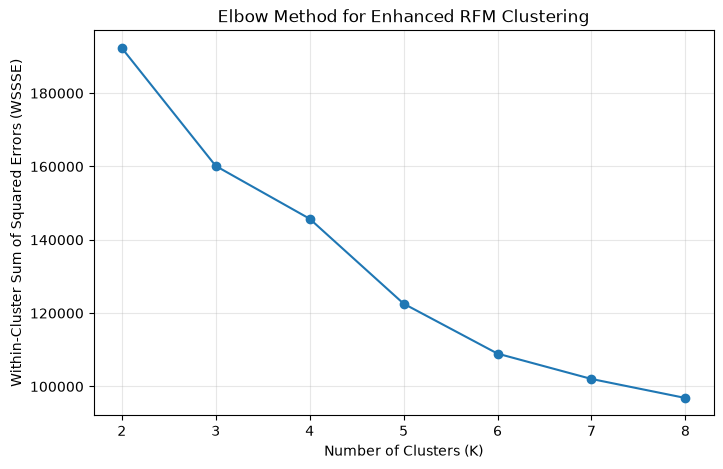

In [18]:
import matplotlib.pyplot as plt

k_plot = [x[0] for x in elbow_results]
wssse_plot = [x[1] for x in elbow_results]

plt.figure(figsize=(8, 5))
plt.plot(k_plot, wssse_plot, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squared Errors (WSSSE)")
plt.title("Elbow Method for Enhanced RFM Clustering")
plt.xticks(k_plot)
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans

silhouette_results = []

evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in [4, 5, 6, 7, 8]:
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled",
        predictionCol="prediction"
    )

    model = kmeans.fit(kmeans_sample)
    predictions = model.transform(kmeans_sample)

    silhouette = evaluator.evaluate(predictions)

    silhouette_results.append((k, silhouette))

    print(f"K={k} | Silhouette Score={silhouette:.4f}")

print("\nSilhouette results:")
for k, score in silhouette_results:
    print(f"K={k}: {score:.4f}")

K=4 | Silhouette Score=0.3194
K=5 | Silhouette Score=0.3635
K=6 | Silhouette Score=0.3952
K=7 | Silhouette Score=0.3480
K=8 | Silhouette Score=0.3796

Silhouette results:
K=4: 0.3194
K=5: 0.3635
K=6: 0.3952
K=7: 0.3480
K=8: 0.3796


In [20]:
from pyspark.ml.clustering import KMeans

final_kmeans = KMeans(
    k=6,
    seed=42,
    featuresCol="features_scaled",
    predictionCol="cluster"
)

final_kmeans_model = final_kmeans.fit(rfm_scaled)

clustered_customers = final_kmeans_model.transform(rfm_scaled)

print("Final K-Means model trained.")
print("Customers clustered:", clustered_customers.count())
print("Number of clusters:", final_kmeans.getK())

Final K-Means model trained.
Customers clustered: 347118
Number of clusters: 6


In [21]:
cluster_sizes = (
    clustered_customers
    .groupBy("cluster")
    .count()
    .orderBy("cluster")
)

cluster_sizes.show()

+-------+------+
|cluster| count|
+-------+------+
|      0| 99824|
|      1| 15363|
|      2|123777|
|      3| 59926|
|      4| 16156|
|      5| 32072|
+-------+------+



In [22]:
from pyspark.sql.functions import avg, min, max, count

cluster_profile = (
    clustered_customers
    .groupBy("cluster")
    .agg(
        count("*").alias("customers"),
        avg("recency_days").alias("avg_recency_days"),
        avg("frequency").alias("avg_frequency"),
        avg("monetary").alias("avg_monetary"),
        avg("average_transaction_value").alias("avg_transaction_value"),
        avg("avg_purchase_events_per_session").alias("avg_events_per_session"),
        avg("amount_slope").alias("avg_amount_slope"),
        avg("frequency_slope").alias("avg_frequency_slope")
    )
    .orderBy("cluster")
)

cluster_profile.show(truncate=False)

+-------+---------+------------------+------------------+------------------+---------------------+----------------------+------------------+---------------------+
|cluster|customers|avg_recency_days  |avg_frequency     |avg_monetary      |avg_transaction_value|avg_events_per_session|avg_amount_slope  |avg_frequency_slope  |
+-------+---------+------------------+------------------+------------------+---------------------+----------------------+------------------+---------------------+
|0      |99824    |17.31297082865844 |1.2033579099214617|70.82542424667447 |61.9406038709046     |1.0141108350697225    |22.983967110497158|-0.00245747533974814 |
|1      |15363    |15.715289982425308|2.862396667317581 |1018.8733795482657|340.9832947297985    |1.8671470956376253    |-59741.79820020241|-1.627286337303912E-4|
|2      |123777   |18.589172463381725|1.3249230470927555|546.098598770368  |423.9145006595945    |1.0000026930151267    |279.4991437711288 |0.0021372537478114447|
|3      |59926    |3.8

In [23]:
from pyspark.sql.functions import expr

cluster_medians = (
    clustered_customers
    .groupBy("cluster")
    .agg(
        expr("percentile_approx(recency_days, 0.5)").alias("median_recency"),
        expr("percentile_approx(frequency, 0.5)").alias("median_frequency"),
        expr("percentile_approx(monetary, 0.5)").alias("median_monetary"),
        expr("percentile_approx(average_transaction_value, 0.5)").alias("median_atv"),
        expr("percentile_approx(avg_purchase_events_per_session, 0.5)").alias("median_events_per_session"),
        expr("percentile_approx(amount_slope, 0.5)").alias("median_amount_slope"),
        expr("percentile_approx(frequency_slope, 0.5)").alias("median_frequency_slope")
    )
    .orderBy("cluster")
)

cluster_medians.show(truncate=False)

+-------+--------------+----------------+------------------+------------------+-------------------------+-------------------+----------------------+
|cluster|median_recency|median_frequency|median_monetary   |median_atv        |median_events_per_session|median_amount_slope|median_frequency_slope|
+-------+--------------+----------------+------------------+------------------+-------------------------+-------------------+----------------------+
|0      |17            |1               |61.74             |52.0              |1.0                      |0.0                |0.0                   |
|1      |16            |2               |604.37            |231.805           |2.0                      |-11107.371093606589|0.0                   |
|2      |18            |1               |351.99            |280.26            |1.0                      |0.0                |0.0                   |
|3      |4             |1               |244.52            |179.67            |1.0                      |0

In [24]:
from pyspark.sql.functions import round, col

total_customers = clustered_customers.count()

cluster_distribution = (
    cluster_sizes
    .withColumn(
        "percentage",
        round(col("count") / total_customers * 100, 2)
    )
)

cluster_distribution.show()

+-------+------+----------+
|cluster| count|percentage|
+-------+------+----------+
|      0| 99824|     28.76|
|      1| 15363|      4.43|
|      2|123777|     35.66|
|      3| 59926|     17.26|
|      4| 16156|      4.65|
|      5| 32072|      9.24|
+-------+------+----------+



In [25]:
CLUSTERED_CUSTOMERS_PATH = "../data/clustered_customers_oct.parquet"

(
    clustered_customers
    .select(
        "user_id",
        "cluster",
        "recency_days",
        "frequency",
        "monetary",
        "average_transaction_value",
        "avg_purchase_events_per_session",
        "amount_slope",
        "frequency_slope"
    )
    .write
    .mode("overwrite")
    .parquet(CLUSTERED_CUSTOMERS_PATH)
)

print("Clustered customer dataset saved successfully.")
print("Path:", CLUSTERED_CUSTOMERS_PATH)

Clustered customer dataset saved successfully.
Path: ../data/clustered_customers_oct.parquet


26/09/28 21:58:30 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/28 21:58:30 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/28 21:58:30 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/28 21:58:30 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/28 21:58:30 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


In [26]:
saved_clustered = spark.read.parquet(CLUSTERED_CUSTOMERS_PATH)

print("Rows:", saved_clustered.count())
print("Columns:", len(saved_clustered.columns))

saved_clustered.printSchema()

Rows: 347118
Columns: 9
root
 |-- user_id: integer (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- average_transaction_value: double (nullable = true)
 |-- avg_purchase_events_per_session: double (nullable = true)
 |-- amount_slope: double (nullable = true)
 |-- frequency_slope: double (nullable = true)



## Final Enhanced RFM and Customer Segmentation Summary

The Enhanced RFM analysis extended the traditional RFM framework using seven customer-level features:

1. Recency
2. Frequency
3. Monetary
4. Average Transaction Value (ATV)
5. Average Purchase Events per Session
6. Amount Slope
7. Frequency Slope

The original transaction-level dataset does not contain an explicit order/transaction identifier or item quantity. Therefore, Average Purchase Events per Session is used as a session-level proxy rather than a true Average Basket Size.

Amount Slope was calculated using the change in purchase price over time. Frequency Slope was calculated from weekly purchase-event frequency over the customer's observed activity period. Customers without sufficient temporal variation receive a slope value of 0.

Because the slope variables showed substantial skew and extreme values, a signed logarithmic transformation was applied to the two slope features. The non-negative behavioral and monetary features were transformed using log1p. The resulting seven features were standardized using Spark StandardScaler before clustering.

K-Means clustering was evaluated using the Elbow Method and Silhouette Score. A 10% reproducible sample containing 34,603 customers was used for K selection. K values from 2 to 8 were evaluated using WSSSE, while K values from 4 to 8 were evaluated using Silhouette Score.

The evaluation supported using K = 6 for the final clustering model. The final K-Means model was then trained on all 347,118 purchasing customers.

The resulting six clusters were profiled using their original Enhanced-RFM feature values. Cluster IDs are model-generated identifiers and were interpreted based on their observed behavioral characteristics rather than assigned arbitrarily.

### Final Cluster Distribution

- Cluster 0: 99,824 customers (28.76%)
- Cluster 1: 15,363 customers (4.43%)
- Cluster 2: 123,777 customers (35.66%)
- Cluster 3: 59,926 customers (17.26%)
- Cluster 4: 16,156 customers (4.65%)
- Cluster 5: 32,072 customers (9.24%)

### Limitations

- The analysis uses October 2019 data only.
- The dataset is event-level rather than explicit order-level data.
- `user_session` is not treated as a formal transaction/order ID.
- Average Purchase Events per Session is therefore a proxy for basket behavior.
- Frequency and monetary values are based on purchase events.
- Slope features can be sensitive to customers with very few purchase observations.
- Cluster labels represent K-Means cluster identifiers and do not inherently imply business value.